# Laboratory Exercises: Knowledge Graphs

## Coverage
- graphs vs knowledge graphs
- property graphs
- RDF basics
- SPARQL
- simple RDFS-style inference
- validation vs inference
- extracting structure from text

Use this version as an answer key or for guided classroom walkthroughs.


In [1]:
#!pip install rdflib
#!pip install networkx

## Setup

In [ ]:
#import sys
#!{sys.executable} -m pip install rdflib

In [2]:
import re
from pprint import pprint

import networkx as nx
from rdflib import Graph, Literal, Namespace, RDF, RDFS

# Part 1. From graphs to knowledge graphs

A graph contains nodes and edges. A knowledge graph adds **meaning**: nodes represent entities or concepts, and edges represent labeled relations.


### Exercise 1.1 — Ordinary graph

Create a small graph of cities connected by roads. Then answer:
1. Which node has the highest degree?
2. What information is still missing if we want this graph to represent *knowledge*?


In [4]:
#import networkx as nx  # Import the NetworkX library for graph creation and analysis

# Create an empty graph object
G = nx.Graph()

# Add edges between nodes (cities in this case)

G.add_node("Belgrade")
G.add_node("Novi Sad")
G.add_node("Kragujevac")
G.add_node("Niš")
# Each tuple represents a connection (edge) between two nodes

G.add_edges_from([
    ('Belgrade', 'Novi Sad'),     # Edge between Belgrade and Novi Sad
    ('Belgrade', 'Kragujevac'),   # Edge between Belgrade and Kragujevac
    ('Belgrade', 'Niš'),          # Edge between Belgrade and Niš
    ('Niš', 'Kragujevac'),        # Edge between Niš and Kragujevac
])

# Print all nodes in the graph
# Nodes are automatically created when edges are added
print('Nodes:', list(G.nodes()))

# Print all edges in the graph
# Each edge is shown as a tuple of connected nodes
print('Edges:', list(G.edges()))

# Print the degree of each node
# Degree = number of connections (edges) a node has
print('Degrees:', dict(G.degree()))

Nodes: ['Belgrade', 'Novi Sad', 'Kragujevac', 'Niš']
Edges: [('Belgrade', 'Novi Sad'), ('Belgrade', 'Kragujevac'), ('Belgrade', 'Niš'), ('Kragujevac', 'Niš')]
Degrees: {'Belgrade': 3, 'Novi Sad': 1, 'Kragujevac': 2, 'Niš': 2}


**Solution:**

- Highest-degree node: **Belgrade** (degree 3)
- Missing semantic information:
  - what the nodes represent beyond just names
  - what the edges mean (road, rail link, administrative relation, etc.)
  - labels, direction, and possibly attributes such as distance or travel time


### Exercise 1.2 — Knowledge graph intuition

In [5]:
# Define a list of facts as tuples (subject, relationship, object)
# This structure is commonly used in knowledge graphs
kg_facts = [
    ('Belgrade', 'isCapitalOf', 'Serbia'),     # Belgrade is the capital of Serbia
    ('Novi Sad', 'locatedIn', 'Serbia'),       # Novi Sad is located in Serbia
    ('Niš', 'locatedIn', 'Serbia'),            # Niš is located in Serbia
    ('Belgrade', 'connectedTo', 'Novi Sad'),   # Belgrade is connected to Novi Sad
]

# Loop through each fact in the list
for fact in kg_facts:
    # Print each fact tuple
    print(fact)

('Belgrade', 'isCapitalOf', 'Serbia')
('Novi Sad', 'locatedIn', 'Serbia')
('Niš', 'locatedIn', 'Serbia')
('Belgrade', 'connectedTo', 'Novi Sad')


**Solution:**

This is more informative because the relationships are explicit.  
For example, `isCapitalOf` and `locatedIn` have different meanings, while an unlabeled edge only says that two nodes are connected somehow.


# Part 2. Property graphs with NetworkX

A property graph stores properties on nodes and edges.


### Exercise 2.1 — Build a small property graph

In [7]:
#import networkx as nx  # Import NetworkX for graph handling

# Create a MultiDiGraph (directed graph that allows multiple edges between nodes)
PG = nx.MultiDiGraph()

# Add nodes with properties (attributes)
PG.add_node('John Smith', label='Person', age=42)  
# Node representing a person with attributes: label and age

PG.add_node('University of Belgrade', label='University', founded=1808)  
# Node representing a university with founding year

PG.add_node('Belgrade', label='City', country='Serbia')  
# Node representing a city with country information


# Add edges with properties
# key distinguishes multiple edges between same nodes
PG.add_edge(
    'John Smith',
    'University of Belgrade',
    key='works_at',
    relation='WORKS_AT',
    since=2021
)
# Directed edge: John Smith WORKS_AT University of Belgrade since 2021

PG.add_edge(
    'University of Belgrade',
    'Belgrade',
    key='located_in',
    relation='LOCATED_IN'
)
# Directed edge: University of Belgrade LOCATED_IN Belgrade

# Print nodes along with their properties
print('Nodes with properties:')
for n, data in PG.nodes(data=True):
    print(n, data)  # n = node name, data = dictionary of attributes

# Print edges along with their properties
print('\nEdges with properties:')
for u, v, k, data in PG.edges(keys=True, data=True):
    # u = source node, v = target node, k = edge key, data = attributes
    print((u, v, k), data)

Nodes with properties:
John Smith {'label': 'Person', 'age': 42}
University of Belgrade {'label': 'University', 'founded': 1808}
Belgrade {'label': 'City', 'country': 'Serbia'}

Edges with properties:
('John Smith', 'University of Belgrade', 'works_at') {'relation': 'WORKS_AT', 'since': 2021}
('University of Belgrade', 'Belgrade', 'located_in') {'relation': 'LOCATED_IN'}


### Exercise 2.2 — Modify the graph

Add the following:
- a node `Database Systems` with label `Course`
- a relation from `John Smith` to `Database Systems`
- a property on the relation: `semester='Spring 2026'`

Then print all outgoing edges from `John Smith`.


In [8]:
# Add a new node representing a course
PG.add_node('Database Systems', label='Course')
# Node has a label indicating it's a Course

# Add a directed edge from John Smith to the course
PG.add_edge(
    'John Smith',
    'Database Systems',
    key='teaches',              # Unique identifier for this edge
    relation='TEACHES',         # Type of relationship
    semester='Spring 2026'      # Additional property
)
# This means: John Smith TEACHES Database Systems in Spring 2026

# Print all outgoing edges from 'John Smith'
print('Outgoing edges from John Smith:')

# Iterate over edges that start from 'John Smith'
for _, target, key, data in PG.out_edges('John Smith', keys=True, data=True):
    # _ = source node (ignored here since it's always 'John Smith')
    # target = destination node
    # key = edge identifier (useful for MultiDiGraph)
    # data = dictionary of edge attributes
    print(('John Smith', target, key), data)

Outgoing edges from John Smith:
('John Smith', 'University of Belgrade', 'works_at') {'relation': 'WORKS_AT', 'since': 2021}
('John Smith', 'Database Systems', 'teaches') {'relation': 'TEACHES', 'semester': 'Spring 2026'}


**Discussion:**

This illustrates a core property-graph feature: **relationships can also carry properties**, such as `since=2021` or `semester='Spring 2026'`.


# Part 3. RDF basics with RDFLib

RDF represents knowledge as triples: **(subject, predicate, object)**.


### Exercise 3.1 — Create a tiny RDF graph

In [18]:
#from rdflib import Graph, Namespace, RDF, Literal  # Import RDFLib components

# Create a namespace (prefix) for your example URIs
EX = Namespace('http://example.org/')

# Create an empty RDF graph
g = Graph()

# Bind the prefix 'ex' to your namespace for readable output
g.bind('ex', EX)

# Add triples to the graph (subject, predicate, object)

g.add((EX.JohnSmith, RDF.type, EX.Person))
# JohnSmith is of type Person

g.add((EX.JohnSmith, EX.worksAt, EX.UniversityOfBelgrade))
# JohnSmith works at UniversityOfBelgrade

g.add((EX.UniversityOfBelgrade, RDF.type, EX.University))
# UniversityOfBelgrade is of type University

g.add((EX.UniversityOfBelgrade, EX.locatedIn, EX.Belgrade))
# UniversityOfBelgrade is located in Belgrade

g.add((EX.Belgrade, RDF.type, EX.City))
# Belgrade is of type City

g.add((EX.Belgrade, EX.country, Literal('Serbia')))
# Belgrade has country "Serbia" (Literal value, not a URI)

# Print the total number of triples in the graph
print(f'Number of triples: {len(g)}')

# Iterate through all triples and print them
for triple in g:
    print(triple)
    # Each triple is a tuple: (subject, predicate, object)

Number of triples: 6
(rdflib.term.URIRef('http://example.org/JohnSmith'), rdflib.term.URIRef('http://example.org/worksAt'), rdflib.term.URIRef('http://example.org/UniversityOfBelgrade'))
(rdflib.term.URIRef('http://example.org/UniversityOfBelgrade'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://example.org/University'))
(rdflib.term.URIRef('http://example.org/UniversityOfBelgrade'), rdflib.term.URIRef('http://example.org/locatedIn'), rdflib.term.URIRef('http://example.org/Belgrade'))
(rdflib.term.URIRef('http://example.org/Belgrade'), rdflib.term.URIRef('http://example.org/country'), rdflib.term.Literal('Serbia'))
(rdflib.term.URIRef('http://example.org/Belgrade'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://example.org/City'))
(rdflib.term.URIRef('http://example.org/JohnSmith'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://exam

### Exercise 3.2 — Add new triples

Add triples saying that:
- `Student` is a class
- `Ana` is a `Student`
- `Ana` studies at `UniversityOfBelgrade`


In [19]:
# Add a new class called "Student" to the graph
g.add((EX.Student, RDF.type, RDFS.Class))

# Declare that "Ana" is an instance of the class "Student"
g.add((EX.Ana, RDF.type, EX.Student))

# Add a property stating that Ana studies at the University of Belgrade
g.add((EX.Ana, EX.studiesAt, EX.UniversityOfBelgrade))

# Print the total number of triples currently stored in the graph
print(f'Updated number of triples: {len(g)}')

# Iterate through all triples where Ana is the subject
for triple in g.triples((EX.Ana, None, None)):
    # Print each triple involving Ana (predicate and object can be anything)
    print(triple)

Updated number of triples: 9
(rdflib.term.URIRef('http://example.org/Ana'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://example.org/Student'))
(rdflib.term.URIRef('http://example.org/Ana'), rdflib.term.URIRef('http://example.org/studiesAt'), rdflib.term.URIRef('http://example.org/UniversityOfBelgrade'))


# Part 4. SPARQL queries

SPARQL matches graph patterns over RDF data.


### Exercise 4.1 — Query for universities and their cities

In [15]:
# Define a SPARQL query as a multi-line string
query = '''
PREFIX ex: <http://example.org/>   # Define prefix for your namespace

SELECT ?university ?city           # Variables to return
WHERE {
  ?university a ex:University .    # Find all resources of type University
  ?university ex:locatedIn ?city . # Get the city where each university is located
}
'''

# Execute the query on the RDF graph
for row in g.query(query):
    # Each row contains values for ?university and ?city
    print(row)

(rdflib.term.URIRef('http://example.org/UniversityOfBelgrade'), rdflib.term.URIRef('http://example.org/Belgrade'))


### Exercise 4.2 — Write your own SPARQL query

In [23]:
# Define a SPARQL query to find people and where they work
query_people_work = '''
PREFIX ex: <http://example.org/>   # Define namespace prefix

SELECT ?person ?org                # Variables to return (person and organization)
WHERE {
  ?person a ex:Person .            # Select all resources of type Person
  ?person ex:studiesAt ?org .        # Find the organization they work at
}
'''

# Execute the query on the RDF graph
for row in g.query(query_people_work):
    # Each row contains values for ?person and ?org
    print(row)

(rdflib.term.URIRef('http://example.org/Ana'), rdflib.term.URIRef('http://example.org/UniversityOfBelgrade'))


**Explanation:**

This query returns every resource typed as `ex:Person` and the organization linked by `ex:worksAt`.


# Part 5. RDFS-style inference

RDFS allows lightweight schema reasoning such as subclass inference.


### Exercise 5.1 — Add a subclass relation

In [20]:
# Declare that Student is a subclass of Person
g.add((EX.Student, RDFS.subClassOf, EX.Person))
# This means: every Student is also considered a Person (inheritance relationship)

# Add (or reinforce) that Ana is a Student
g.add((EX.Ana, RDF.type, EX.Student))
# Ana belongs to the Student class

# Note: With reasoning enabled, Ana would also be inferred as a Person
# even if we didn't explicitly add (EX.Ana, RDF.type, EX.Person)

# Print a message confirming the update
print('Explicit triples added for subclass reasoning.')

Explicit triples added for subclass reasoning.


### Exercise 5.2 - Manual inference

Implement the rule:

If `(x rdf:type A)` and `(A rdfs:subClassOf B)`, infer `(x rdf:type B)`.


In [22]:
# Create a list to store newly inferred triples
new_triples = []

# Loop over all triples of the form (x, rdf:type, A)
# Meaning: x is an instance of class A
for x, _, A in g.triples((None, RDF.type, None)):
    
    # For each class A, check if it has a superclass B
    # (A rdfs:subClassOf B)
    for _, _, B in g.triples((A, RDFS.subClassOf, None)):
        
        # Create a new inferred triple:
        # If x is an A, and A is a subclass of B,
        # then x is also a B
        candidate = (x, RDF.type, B)
        
        # Add only if it's not already in the graph
        if candidate not in g:
            new_triples.append(candidate)

# Add all newly inferred triples to the graph
for triple in new_triples:
    g.add(triple)

# Print all inferred triples
print('Inferred triples:')
for triple in new_triples:
    print(triple)

Inferred triples:
(rdflib.term.URIRef('http://example.org/Ana'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://example.org/Person'))


In [25]:
print(f'Updated number of triples: {len(g)}')
for triple in g:
    print(triple)
    # Each triple is a tuple: (subject, predicate, object)

Updated number of triples: 11
(rdflib.term.URIRef('http://example.org/Student'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://www.w3.org/2000/01/rdf-schema#Class'))
(rdflib.term.URIRef('http://example.org/Ana'), rdflib.term.URIRef('http://example.org/studiesAt'), rdflib.term.URIRef('http://example.org/UniversityOfBelgrade'))
(rdflib.term.URIRef('http://example.org/Student'), rdflib.term.URIRef('http://www.w3.org/2000/01/rdf-schema#subClassOf'), rdflib.term.URIRef('http://example.org/Person'))
(rdflib.term.URIRef('http://example.org/JohnSmith'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://example.org/Person'))
(rdflib.term.URIRef('http://example.org/Ana'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://example.org/Student'))
(rdflib.term.URIRef('http://example.org/JohnSmith'), rdflib.term.URIRef('http://example.org/worksAt'), rdfli

**Solution:**

The fact that becomes implicit before inference and explicit after materialization is:

- `(ex:Ana, rdf:type, ex:Person)`

because `Student rdfs:subClassOf Person` and `Ana rdf:type Student`.


# Part 6. Validation vs inference

Inference derives new facts. Validation checks whether data conforms to constraints.


### Exercise 6.1 - Simple validation rule

In [26]:
from pprint import pprint  # Import pprint for nicely formatted output

# Sample data: entities with their attributes
data = {
    'Ana': {'type': 'Student', 'age': 21},        # Valid: has integer age
    'Marko': {'type': 'Student'},                 # Invalid: missing age
    'Ivana': {'type': 'Student', 'age': 'twenty'} # Invalid: age is not an integer
}

# List to store validation errors (violations)
violations = []

# Iterate through each entity and its attributes
for entity, attrs in data.items():
    
    # Check only entities of type 'Student'
    if attrs.get('type') == 'Student':
        
        # Rule 1: Student must have an 'age' attribute
        if 'age' not in attrs:
            violations.append((entity, 'missing age'))
        
        # Rule 2: Age must be an integer
        elif not isinstance(attrs['age'], int):
            violations.append((entity, 'age must be an integer'))

# Print all detected violations
print('Violations:')
pprint(violations)

Violations:
[('Marko', 'missing age'), ('Ivana', 'age must be an integer')]


**Solution: Why is this validation and not inference?**

Because we are not deriving new facts.  
We are checking whether existing data satisfies a constraint: *every student must have an integer age*.


# Part 7. From unstructured text to structured facts

KG construction often starts from text.


### Exercise 7.1 - Rule-based extraction

In [36]:
import re
from pprint import pprint  # For nicely formatted output

# Input text to extract structured information from
text = ['John Smith joined Harvard University as a professor.', 
        "Petar Petrovic joined University of Belgrade as a assistant."]
# Regular expression pattern with named groups:
# - person: captures the name before "joined"
# - org: captures the organization after "joined"
# - role: captures the role after "as a"
pattern = r'^(?P<person>.+?) joined (?P<org>.+?) as a (?P<role>.+?)\.$'


# Try to match the pattern against the text
for tx in text:
    match = re.match(pattern, tx)

    # If the pattern matches, extract the information
    if match:
        person = match.group('person')  # Extract person's name
        org = match.group('org')        # Extract organization name
        role = match.group('role')      # Extract role
    
        # Create triples (subject, predicate, object)
        triples = [
            (person, 'worksAt', org),           # Relationship: person works at organization
            (person, 'hasRole', role.title()),  # Normalize role (capitalize) and assign
        ]
    
        # Print extracted triples
        pprint(triples)

    else:
        # If the text does not match the pattern
        print('No match')

[('John Smith', 'worksAt', 'Harvard University'),
 ('John Smith', 'hasRole', 'Professor')]
[('Petar Petrovic', 'worksAt', 'University of Belgrade'),
 ('Petar Petrovic', 'hasRole', 'Assistant')]


### Exercise 7.2 - Extend the extractor

In [39]:
import re
from pprint import pprint  # For nicely formatted output

# Input text to extract structured data from
text2 = ['Harvard University is located in Cambridge.', "University of Belgrade is located in Belgrade."]

# Regular expression pattern with named groups:
# - org: captures the organization name
# - city: captures the city name
pattern2 = r'^(?P<org>.+?) is located in (?P<city>.+?)\.$'

# Try to match the pattern against the text
for tx in text2:
    match2 = re.match(pattern2, tx)

    # If the pattern matches, extract the information
    if match2:
        org = match2.group('org')    # Extract organization name
        city = match2.group('city')  # Extract city name
    
        # Create a triple (subject, predicate, object)
        triple = (org, 'locatedIn', city)
    
        # Print the extracted triple
        pprint(triple)

    else:
        # If the text does not match the expected pattern
        print('No match')

('Harvard University', 'locatedIn', 'Cambridge')
('University of Belgrade', 'locatedIn', 'Belgrade')


**Discussion:**

This is a very simple rule-based form of information extraction.  
In realistic KG construction pipelines, NER, relation extraction, entity linking, and often LLM-based extraction are used instead.


### Exercise 7.3 - Realistic example

In [ ]:
#!pip install -U pip setuptools wheel
#!pip install -U spacy
#!pip install pandas

In [40]:
texts = [
"Apple is planning to release a new iPhone model next month.",    
"Samsung unveiled its latest flagship smartphone at the tech conference.",    
"Google is investing heavily in artificial intelligence research.",    
"Microsoft announced a major update for its Windows operating system.",    
"Amazon launched a new line of smart home devices.",    
"Google faced criticism over its data privacy policies.",    
"Tesla's CEO Elon Musk tweeted about the company's future plans.",    
"Uber is expanding its services to additional cities worldwide.",    
"Netflix released a teaser for its upcoming original series.",    
"Apple introduced new features for its social media platform."
]

In [41]:
import pandas as pd 
import spacy

In [ ]:
#import sys
#!{sys.executable} -m spacy download en_core_web_md

In [42]:
import spacy  # Import the spaCy NLP library

# Load a pre-trained English language model
nlp = spacy.load("en_core_web_md")
# "en_core_web_md" is a medium-sized model that includes:
# - Tokenization (splitting text into words)
# - Part-of-speech tagging
# - Named entity recognition (NER)
# - Word vectors (useful for similarity)

# The 'nlp' object is now a pipeline you can use to process text

In [43]:
data = {'text': [], 'entities': [], 'labels': []}

In [48]:
text="Jon Smith joined University of Belgrde located in Belgrade"
doc = nlp(text) 
entities = [ent.text for ent in doc.ents]  
print(entities)
labels = [ent.label_ for ent in doc.ents]
print(labels)

['Jon Smith', 'University of Belgrde', 'Belgrade']
['PERSON', 'ORG', 'GPE']


In [49]:
# Loop through a list of input texts
for text in texts: 
    
    # Process the text using the spaCy NLP pipeline
    doc = nlp(text) 
    
    # Extract named entities (e.g., people, organizations, locations)
    entities = [ent.text for ent in doc.ents]  
    # Example: ['John Smith', 'Harvard University']
    
    # Extract corresponding entity labels (types)
    labels = [ent.label_ for ent in doc.ents]
    # Example: ['PERSON', 'ORG']
    
    # Store results in a data structure (dictionary with lists)
    data['text'].append(text)         # Original text
    data['entities'].append(entities) # Extracted entities
    data['labels'].append(labels)     # Entity types

In [50]:
data

{'text': ['Apple is planning to release a new iPhone model next month.',
  'Samsung unveiled its latest flagship smartphone at the tech conference.',
  'Google is investing heavily in artificial intelligence research.',
  'Microsoft announced a major update for its Windows operating system.',
  'Amazon launched a new line of smart home devices.',
  'Google faced criticism over its data privacy policies.',
  "Tesla's CEO Elon Musk tweeted about the company's future plans.",
  'Uber is expanding its services to additional cities worldwide.',
  'Netflix released a teaser for its upcoming original series.',
  'Apple introduced new features for its social media platform.'],
 'entities': [['Apple', 'iPhone', 'next month'],
  ['Samsung'],
  ['Google'],
  ['Microsoft', 'Windows'],
  ['Amazon'],
  [],
  ['Tesla', 'Elon Musk'],
  [],
  ['Netflix'],
  ['Apple']],
 'labels': [['ORG', 'ORG', 'DATE'],
  ['ORG'],
  ['ORG'],
  ['ORG', 'PRODUCT'],
  ['ORG'],
  [],
  ['ORG', 'PERSON'],
  [],
  ['ORG'],


In [54]:
sp_df=pd.DataFrame(columns=["1", "2","3"])

In [55]:
sp_df

,1,2,3


In [56]:
sp_df = pd.DataFrame(data)

In [57]:
sp_df.reset_index(inplace=True)

In [58]:
sp_df

,index,text,entities,labels
0,0,Apple is planning to release a new iPhone mode...,"[Apple, iPhone, next month]","[ORG, ORG, DATE]"
1,1,Samsung unveiled its latest flagship smartphon...,[Samsung],[ORG]
2,2,Google is investing heavily in artificial inte...,[Google],[ORG]
3,3,Microsoft announced a major update for its Win...,"[Microsoft, Windows]","[ORG, PRODUCT]"
4,4,Amazon launched a new line of smart home devices.,[Amazon],[ORG]
5,5,Google faced criticism over its data privacy p...,[],[]
6,6,Tesla's CEO Elon Musk tweeted about the compan...,"[Tesla, Elon Musk]","[ORG, PERSON]"
7,7,Uber is expanding its services to additional c...,[],[]
8,8,Netflix released a teaser for its upcoming ori...,[Netflix],[ORG]
9,9,Apple introduced new features for its social m...,[Apple],[ORG]


In [59]:
sp_df_exploded = sp_df.explode(["entities", "labels"])

filtered_sp_df = sp_df_exploded[sp_df_exploded["labels"].isin(["ORG", "PERSON", "PRODUCT", "DATE"])].reset_index(drop=True)

filtered_sp_df

,index,text,entities,labels
0,0,Apple is planning to release a new iPhone mode...,Apple,ORG
1,0,Apple is planning to release a new iPhone mode...,iPhone,ORG
2,0,Apple is planning to release a new iPhone mode...,next month,DATE
3,1,Samsung unveiled its latest flagship smartphon...,Samsung,ORG
4,2,Google is investing heavily in artificial inte...,Google,ORG
5,3,Microsoft announced a major update for its Win...,Microsoft,ORG
6,3,Microsoft announced a major update for its Win...,Windows,PRODUCT
7,4,Amazon launched a new line of smart home devices.,Amazon,ORG
8,6,Tesla's CEO Elon Musk tweeted about the compan...,Tesla,ORG
9,6,Tesla's CEO Elon Musk tweeted about the compan...,Elon Musk,PERSON


In [63]:
text="Jon Smith joined University of Belgrde located in Belgrade"
doc= nlp(text)
verbs = [token.lemma_ for token in doc if token.pos_ == "VERB"]
print(verbs)

['join', 'locate']


In [64]:
# Function to extract (subject, relation, object) from text
def extract_entity_relation_triplet(text):
    
    # Process the text using spaCy
    doc = nlp(text)
    
    # Extract named entities with:
    # (text, label, start index, end index)
    entities = [(ent.text, ent.label_, ent.start, ent.end) for ent in doc.ents]
    
    # Extract all verbs in the sentence (lemmatized form)
    verbs = [token.lemma_ for token in doc if token.pos_ == "VERB"]
    
    # Case 1: At least two entities and at least one verb
    if len(entities) >= 2 and verbs:
        return {
            "subject": entities[0][0],        # First entity as subject
            "subject_type": entities[0][1],   # Entity label (e.g., PERSON)
            "relation": verbs[0],             # First verb as relation
            "object": entities[1][0],         # Second entity as object
            "object_type": entities[1][1]     # Entity label (e.g., ORG)
        }
    
    # Case 2: Only one entity but at least one verb
    elif len(entities) == 1 and verbs:
        return {
            "subject": entities[0][0],
            "subject_type": entities[0][1],
            "relation": verbs[0],
            "object": None,                  # No second entity found
            "object_type": None
        }
    
    # Case 3: Not enough information to form a triplet
    else:
        return None




In [65]:
# List to collect extracted triplets
triples = []

# Iterate over text column in a DataFrame (sp_df)
for text in sp_df["text"]:
    
    # Extract triplet from each text
    result = extract_entity_relation_triplet(text)
    
    # If a valid triplet is found, store it
    if result:
        result["text"] = text  # Keep original sentence
        triples.append(result)

# Convert results into a pandas DataFrame
triples_df = pd.DataFrame(triples)

# Display the resulting DataFrame
triples_df

,subject,subject_type,relation,object,object_type,text
0,Apple,ORG,plan,iPhone,ORG,Apple is planning to release a new iPhone mode...
1,Samsung,ORG,unveil,None,None,Samsung unveiled its latest flagship smartphon...
2,Google,ORG,invest,None,None,Google is investing heavily in artificial inte...
3,Microsoft,ORG,announce,Windows,PRODUCT,Microsoft announced a major update for its Win...
4,Amazon,ORG,launch,None,None,Amazon launched a new line of smart home devices.
5,Tesla,ORG,tweet,Elon Musk,PERSON,Tesla's CEO Elon Musk tweeted about the compan...
6,Netflix,ORG,release,None,None,Netflix released a teaser for its upcoming ori...
7,Apple,ORG,introduce,None,None,Apple introduced new features for its social m...


In [66]:
# Function to extract a knowledge graph triple using simple rules
def rule_based_kg_triple(text):
    
    # Process the text with spaCy NLP pipeline
    doc = nlp(text)
    
    # Extract named entities from the text
    ents = list(doc.ents)
    
    # --- Rule 1: Special pattern for CEO relationships ---
    # If the word "CEO" appears and we have at least two entities
    if "CEO" in text and len(ents) >= 2:
        
        # Extract organizations and persons separately
        orgs = [e.text for e in ents if e.label_ == "ORG"]
        persons = [e.text for e in ents if e.label_ == "PERSON"]
        
        # If both an organization and a person exist
        if orgs and persons:
            return (orgs[0], "hasCEO", persons[0])
            # Example: ("Tesla", "hasCEO", "Elon Musk")
    
    # --- Rule 2: Generic subject-verb-object extraction ---
    
    # Extract verbs (lemmatized)
    verbs = [t.lemma_ for t in doc if t.pos_ == "VERB"]
    
    # If there are at least two entities and at least one verb
    if len(ents) >= 2 and verbs:
        
        # Assume:
        # - first entity = subject
        # - first verb = relation
        # - second entity = object
        subject = ents[0].text
        relation = verbs[0]
        obj = ents[1].text
        
        return (subject, relation, obj)
    
    # --- No rule matched ---
    return None

In [67]:
# Iterate through each text entry in the DataFrame column
for text in sp_df["text"]:
    
    # Extract a triple using the rule-based function
    triple = rule_based_kg_triple(text)
    
    # Check:
    # - triple is not None (a rule matched)
    # - object (third element) is not None (complete relation)
    if triple is not None and triple[2] is not None:
        
        # Print the valid (subject, relation, object) triple
        print(triple)

('Apple', 'plan', 'iPhone')
('Microsoft', 'announce', 'Windows')
('Tesla', 'hasCEO', 'Elon Musk')


Spacy is capable of only detecting some of the PRODUCTs. Let us use Gemma 1b to do a better detection. 

In [ ]:
#!pip install google-generativeai

In [68]:
import google.generativeai as genai

genai.configure(api_key="")

In [69]:
# Use a safe model name (update if needed)
MODEL_NAME = "gemma-3-1b-it"

model = genai.GenerativeModel(MODEL_NAME)


In [73]:
#Prompt for entity detection
def build_prompt(sentence):
    return f"""
Extract named entities from the sentence.

Return ONLY valid JSON in this format:
{{
  "entities": [
    {{"text": "...", "label": "ORG|PERSON|PRODUCT|DATE"}}
  ]
}}

Rules:
- Only extract entities present in the text
- Do not hallucinate
- Do not include explanations
- Use only labels: ORG, PERSON, PRODUCT, DATE, EVENT

Sentence:
"{sentence}"
"""

In [74]:
sentence = "Apple is planning to release a new iPhone model next month at the tech conference."

response = model.generate_content(build_prompt(sentence))

print(response.text)

```json
{
  "entities": [
    {"text": "Apple", "label": "ORG"},
    {"text": "iPhone", "label": "PRODUCT"},
    {"text": "month", "label": "DATE"},
    {"text": "tech conference", "label": "EVENT"}
  ]
}
```


In [75]:
import json
import re

# Function to safely parse JSON from a text response
def parse_json_response(text):
    try:
        # Attempt 1: Directly parse the text as JSON
        return json.loads(text)
    
    except:
        # If direct parsing fails, try extracting a JSON object from the text
        
        # Search for a JSON-like block using regex
        match = re.search(r'\{.*\}', text, re.DOTALL)
        
        if match:
            # Attempt 2: Parse the extracted JSON substring
            return json.loads(match.group())
        
        else:
            # If no JSON structure is found, return None
            return None

# Apply the function to a response (e.g., from an API)
parsed = parse_json_response(response.text)

# Print the parsed JSON object (dictionary or list)
print(parsed)

{'entities': [{'text': 'Apple', 'label': 'ORG'}, {'text': 'iPhone', 'label': 'PRODUCT'}, {'text': 'month', 'label': 'DATE'}, {'text': 'tech conference', 'label': 'EVENT'}]}


In [76]:
# List to store extracted entities from all texts
results = []

# Loop through each text in the DataFrame
for text in texts:
    
    # Build a prompt for the LLM (likely instructing it to extract entities)
    prompt = build_prompt(text)
    
    # Send the prompt to the model and get a response
    response = model.generate_content(prompt)
    
    # Parse the response (expects JSON, with fallback handling)
    parsed = parse_json_response(response.text)
    
    # If parsing was successful
    if parsed:
        
        # Iterate through extracted entities in the JSON response
        for ent in parsed["entities"]:
            
            # Append each entity as a structured record
            results.append({
                "text": text,              # Original input text
                "entity": ent["text"],     # Extracted entity text
                "label": ent["label"]      # Entity type (e.g., PERSON, ORG)
            })

# Convert results into a pandas DataFrame
llm_entities_df = pd.DataFrame(results)

# Display the DataFrame
llm_entities_df

,text,entity,label
0,Apple is planning to release a new iPhone mode...,Apple,ORG
1,Apple is planning to release a new iPhone mode...,iPhone,PRODUCT
2,Apple is planning to release a new iPhone mode...,next month,DATE
3,Samsung unveiled its latest flagship smartphon...,Samsung,ORG
4,Samsung unveiled its latest flagship smartphon...,smartphone,PRODUCT
5,Samsung unveiled its latest flagship smartphon...,tech conference,EVENT
6,Google is investing heavily in artificial inte...,Google,ORG
7,Google is investing heavily in artificial inte...,artificial intelligence,PRODUCT
8,Google is investing heavily in artificial inte...,research,EVENT
9,Microsoft announced a major update for its Win...,Microsoft,ORG


In [77]:
#Prompt for relation extraction
def build_relation_prompt(sentence):
    return f"""
Extract relationships from the sentence and return them as JSON.

Return ONLY valid JSON in this format:
{{
  "relations": [
    {{
      "subject": "...",
      "relation": "...",
      "object": "..."
    }}
  ]
}}

Rules:
- Extract only relations explicitly supported by the sentence
- Do not infer unstated facts
- Preserve entity text as it appears in the sentence
- Use short relation names in snake_case
- If no relation is present, return {{"relations": []}}
- Do not include explanations, comments, or extra text

Sentence:
"{sentence}"
"""

In [78]:
sentence = "Apple is planning to release a new iPhone model next month."

response = model.generate_content(build_relation_prompt(sentence))

print(response.text)

```json
{
  "relations": [
    {
      "subject": "Apple",
      "relation": "planning to release",
      "object": "new iPhone model"
    }
  ]
}
```


In [79]:
import json
import re

def parse_json_response(text):
    try:
        return json.loads(text)
    except:
        match = re.search(r'\{.*\}', text, re.DOTALL)
        if match:
            return json.loads(match.group())
        return None

In [80]:
sentence = "Apple is planning to release a new iPhone model next month."

response = model.generate_content(build_relation_prompt(sentence))
parsed = parse_json_response(response.text)

print(response.text)
print(parsed)

```json
{
  "relations": [
    {
      "subject": "Apple",
      "relation": "planning to release",
      "object": "new iPhone model"
    }
  ]
}
```
{'relations': [{'subject': 'Apple', 'relation': 'planning to release', 'object': 'new iPhone model'}]}


In [81]:
# List to store extracted relations
relation_rows = []

# Loop through each text in the DataFrame
for text in texts:
    
    # Generate a prompt specifically for relation extraction
    response = model.generate_content(build_relation_prompt(text))
    
    # Parse the model's response (expects JSON format)
    parsed = parse_json_response(response.text)

    # Check if parsing succeeded and "relations" key exists
    if parsed and "relations" in parsed:
        
        # Iterate over each extracted relation
        for rel in parsed["relations"]:
            
            # Safely extract subject, relation, and object
            subject = rel.get("subject")
            relation = rel.get("relation")
            obj = rel.get("object")

            # Only keep complete triples (no missing values)
            if subject and relation and obj: 
                relation_rows.append({
                    "text": text,        # Original sentence
                    "subject": subject,  # Subject entity
                    "relation": relation,# Relationship type
                    "object": obj        # Object entity
                })

# Convert the list of relations into a pandas DataFrame
relations_df = pd.DataFrame(relation_rows)

# Display the resulting DataFrame
relations_df

,text,subject,relation,object
0,Apple is planning to release a new iPhone mode...,Apple,planning to release,new iPhone model
1,Samsung unveiled its latest flagship smartphon...,Samsung,unveiled,its latest flagship smartphone
2,Samsung unveiled its latest flagship smartphon...,tech conference,at,the event
3,Google is investing heavily in artificial inte...,Google,investing,artificial intelligence research
4,Microsoft announced a major update for its Win...,Microsoft,announced,Windows operating system
5,Amazon launched a new line of smart home devices.,Amazon,launched,new line of smart home devices
6,Google faced criticism over its data privacy p...,Google,faced criticism,its data privacy policies
7,Tesla's CEO Elon Musk tweeted about the compan...,Tesla,tweeted,Elon Musk
8,Tesla's CEO Elon Musk tweeted about the compan...,Elon Musk,CEO,Tesla
9,Uber is expanding its services to additional c...,Uber,expanding,its services


In [83]:
from rdflib import Graph, Namespace, Literal  # Import RDFLib core classes
from rdflib.namespace import RDF              # Import RDF vocabulary (e.g., rdf:type)
import re                                     # Import regex for text cleaning

# Define a namespace for your knowledge graph
EX = Namespace("http://tech.org/")

# Create a new RDF graph
g = Graph()

# Bind the prefix "ex" to your namespace (for readable output like ex:Entity)
g.bind("ex", EX)

# Function to normalize text into a valid URI-friendly format
def normalize(text):
    text = str(text).strip()                  # Convert to string and remove leading/trailing spaces
    
    text = re.sub(r"\s+", "_", text)          # Replace spaces with underscores
    # Example: "John Smith" → "John_Smith"
    
    text = re.sub(r"[^A-Za-z0-9_]", "", text) # Remove special characters
    # Keeps only letters, numbers, and underscores
    
    return text                              # Return cleaned text

In [84]:
# Iterate over each row in the DataFrame containing LLM-extracted entities
for _, row in llm_entities_df.iterrows():
    
    # Extract entity text and its label (type)
    entity = row["entity"]
    label = row["label"]
    #print(entity, label)
    # Ensure both entity and label are present
    if entity and label:
        
        # Normalize entity and label to create URI-friendly identifiers
        entity_uri = EX[normalize(entity)]  # e.g., "John Smith" → ex:John_Smith
        label_uri = EX[normalize(label)]    # e.g., "PERSON" → ex:PERSON
        
        # Add RDF triple: (entity, rdf:type, label)
        g.add((entity_uri, RDF.type, label_uri))
        # Example: (ex:John_Smith, rdf:type, ex:PERSON)

In [85]:
# Iterate over each row in the DataFrame containing extracted relations
for _, row in relations_df.iterrows():
    
    # Extract subject, relation (predicate), and object
    subject = row["subject"]
    relation = row["relation"]
    obj = row["object"]
    
    # Ensure all parts of the triple exist
    if subject and relation and obj:
        
        # Normalize and convert subject and predicate into URIs
        subj_uri = EX[normalize(subject)]   # e.g., "John Smith" → ex:John_Smith
        pred_uri = EX[normalize(relation)]  # e.g., "worksAt" → ex:worksAt
        
        # --- Smarter object handling ---
        # If object is more like a literal value (not an entity), store as Literal
        if obj.lower() in ["next month", "worldwide"]:
            obj_node = Literal(obj)  # Keep as plain text value
        else:
            # Otherwise treat object as an entity (URI)
            obj_node = EX[normalize(obj)]
        
        # Add the triple to the RDF graph
        g.add((subj_uri, pred_uri, obj_node))
        # Example:
        # (ex:John_Smith, ex:worksAt, ex:Harvard_University)
        # OR
        # (ex:Company, ex:launchDate, "next month")

In [86]:
print(f"Number of triples: {len(g)}")

for triple in g:
    print(triple)

Number of triples: 37
(rdflib.term.URIRef('http://tech.org/smartphone'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://tech.org/PRODUCT'))
(rdflib.term.URIRef('http://tech.org/Elon_Musk'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://tech.org/PERSON'))
(rdflib.term.URIRef('http://tech.org/Apple'), rdflib.term.URIRef('http://tech.org/planning_to_release'), rdflib.term.URIRef('http://tech.org/new_iPhone_model'))
(rdflib.term.URIRef('http://tech.org/Google'), rdflib.term.URIRef('http://tech.org/faced_criticism'), rdflib.term.URIRef('http://tech.org/its_data_privacy_policies'))
(rdflib.term.URIRef('http://tech.org/Elon_Musk'), rdflib.term.URIRef('http://tech.org/CEO'), rdflib.term.URIRef('http://tech.org/Tesla'))
(rdflib.term.URIRef('http://tech.org/Windows'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://tech.org/PRODUCT'))
(rdflib.te

In [88]:
# Define a SPARQL query to retrieve all objects related to ex:Apple
query = """
PREFIX ex: <http://tech.org/>

SELECT ?obj
WHERE {
    ex:Apple ?pred ?obj .   # Match any predicate and object for subject ex:Apple
}
"""

# Execute the query on the RDF graph
for row in g.query(query):
    
    # Each row contains a value for ?obj
    print(row)

(rdflib.term.URIRef('http://tech.org/ORG'),)
(rdflib.term.URIRef('http://tech.org/new_iPhone_model'),)
(rdflib.term.URIRef('http://tech.org/new_features'),)


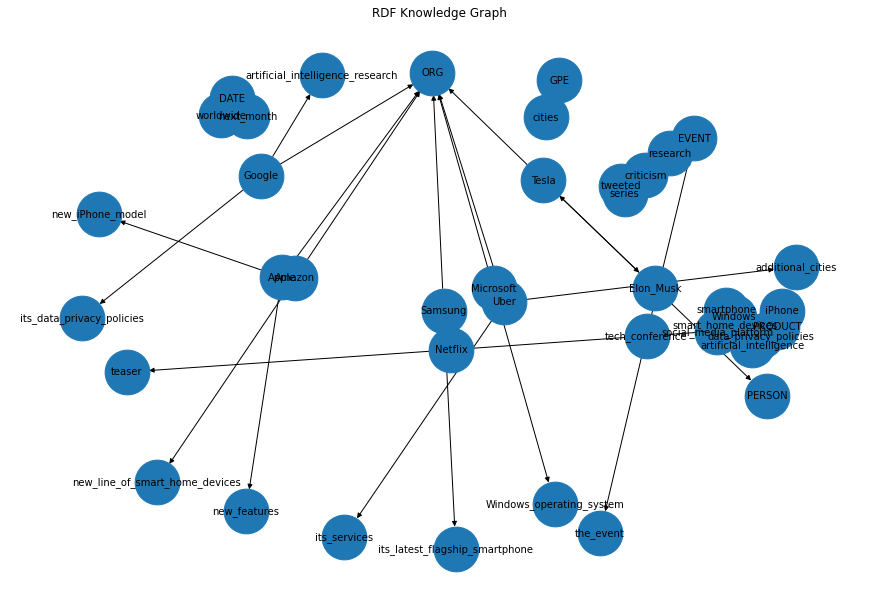

In [91]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph (since RDF triples are directional)
G_nx = nx.DiGraph()

# Iterate over all triples in the RDF graph
for s, p, o in g:
    
    # Extract readable labels from URIs (last part after "/")
    s_label = str(s).split("/")[-1]  # Subject label
    p_label = str(p).split("/")[-1]  # Predicate (edge label)
    o_label = str(o).split("/")[-1]  # Object label
    
    # Add nodes to the graph (NetworkX ignores duplicates automatically)
    G_nx.add_node(s_label)
    G_nx.add_node(o_label)
    
    # Add a directed edge with a label (predicate)
    G_nx.add_edge(s_label, o_label, label=p_label)

# Create a figure for visualization
plt.figure(figsize=(12, 8))

# Compute positions for nodes using a force-directed layout
pos = nx.spring_layout(G_nx)

# Draw the graph (nodes + edges)
nx.draw(
    G_nx, pos,
    with_labels=True,   # Show node labels
    node_size=2000,     # Size of nodes
    font_size=10,       # Label font size
    arrows=True         # Show direction of edges
)

# Extract edge labels (predicates)
edge_labels = nx.get_edge_attributes(G_nx, "label")

# Draw edge labels on the graph
'''
nx.draw_networkx_edge_labels(
    G_nx, pos,
    edge_labels=edge_labels,
    font_size=9
)
'''
# Add title and remove axes
plt.title("RDF Knowledge Graph")
plt.axis("off")

# Display the graph
plt.show()